In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/marmurrr/air-raid/official_data_en.csv
/kaggle/input/datasets/marmurrr/volunteer-air-raid/volunteer_data_en.csv


In [2]:
#imports
import seaborn as sns
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df_o = pd.read_csv('/kaggle/input/datasets/marmurrr/air-raid/official_data_en.csv')
print(df_o.head(2))

               oblast raion hromada   level                 started_at  \
0    Vinnytska oblast   NaN     NaN  oblast  2022-03-15 16:10:34+00:00   
1  Zhytomyrska oblast   NaN     NaN  oblast  2022-03-15 16:11:25+00:00   

                 finished_at    source  
0  2022-03-15 16:50:07+00:00  official  
1  2022-03-15 16:54:23+00:00  official  


In [4]:
df_v = pd.read_csv('/kaggle/input/datasets/marmurrr/volunteer-air-raid/volunteer_data_en.csv')
print(df_v.head(2))

             region                 started_at                finished_at  \
0         Kyiv City  2022-02-25 16:36:22+00:00  2022-02-25 17:06:22+00:00   
1  Cherkaska oblast  2022-02-25 18:36:21+00:00  2022-02-25 19:32:11+00:00   

   naive  
0   True  
1  False  


In [5]:
for df in [df_o, df_v]:
    df["started_at"] = pd.to_datetime(df["started_at"], utc=True)
    df["finished_at"] = pd.to_datetime(df["finished_at"], utc=True)

In [6]:
df_o["duration"] = (
    df_o["finished_at"] - df_o["started_at"]
).dt.total_seconds() / 60

df_v["duration"] = (
    df_v["finished_at"] - df_v["started_at"]
).dt.total_seconds() / 60

In [7]:
df_o = df_o[df_o["duration"] >= 0]
df_v = df_v[df_v["duration"] >= 0]

In [8]:
df_v["date"] = df_v["started_at"].dt.date
df_v["year"] = df_v["started_at"].dt.year
df_v["month"] = df_v["started_at"].dt.month
df_v["weekday"] = df_v["started_at"].dt.day_name()
df_v["hour"] = df_v["started_at"].dt.hour

In [9]:
df_o[df_o["oblast"] == 'Vinnytska oblast']

,oblast,raion,hromada,level,started_at,finished_at,source,duration
0,Vinnytska oblast,NaN,NaN,oblast,2022-03-15 16:10:34+00:00,2022-03-15 16:50:07+00:00,official,39.550000
18,Vinnytska oblast,NaN,NaN,oblast,2022-03-15 16:52:30+00:00,2022-03-15 17:24:19+00:00,official,31.816667
28,Vinnytska oblast,NaN,NaN,oblast,2022-03-15 18:09:10+00:00,2022-03-15 18:24:49+00:00,official,15.650000
57,Vinnytska oblast,NaN,NaN,oblast,2022-03-16 00:57:14+00:00,2022-03-16 03:21:06+00:00,official,143.866667
71,Vinnytska oblast,NaN,NaN,oblast,2022-03-16 07:51:35+00:00,2022-03-16 09:04:12+00:00,official,72.616667
...,...,...,...,...,...,...,...,...
272479,Vinnytska oblast,Tulchynskyi raion,NaN,raion,2026-06-22 12:35:00+00:00,2026-06-22 12:58:06+00:00,official,23.100000
272480,Vinnytska oblast,Vinnytskyi raion,NaN,raion,2026-06-22 12:35:00+00:00,2026-06-22 12:58:06+00:00,official,23.100000
272481,Vinnytska oblast,Haisynskyi raion,NaN,raion,2026-06-22 12:35:00+00:00,2026-06-22 12:58:06+00:00,official,23.100000
272482,Vinnytska oblast,Khmilnytskyi raion,NaN,raion,2026-06-22 12:35:00+00:00,2026-06-22 12:58:06+00:00,official,23.100000


In [10]:
df_v

,region,started_at,finished_at,naive,duration,date,year,month,weekday,hour
0,Kyiv City,2022-02-25 16:36:22+00:00,2022-02-25 17:06:22+00:00,True,30.000000,2022-02-25,2022,2,Friday,16
1,Cherkaska oblast,2022-02-25 18:36:21+00:00,2022-02-25 19:32:11+00:00,False,55.833333,2022-02-25,2022,2,Friday,18
2,Rivnenska oblast,2022-02-25 18:56:44+00:00,2022-02-25 19:26:44+00:00,True,30.000000,2022-02-25,2022,2,Friday,18
3,Zaporizka oblast,2022-02-25 18:57:51+00:00,2022-02-25 19:27:51+00:00,True,30.000000,2022-02-25,2022,2,Friday,18
4,Volynska oblast,2022-02-25 19:41:57+00:00,2022-02-26 04:01:55+00:00,False,499.966667,2022-02-25,2022,2,Friday,19
...,...,...,...,...,...,...,...,...,...,...
101700,Dnipropetrovska oblast,2026-06-22 23:53:13+00:00,2026-06-23 00:13:21+00:00,False,20.133333,2026-06-22,2026,6,Monday,23
101701,Kharkivska oblast,2026-06-23 00:11:29+00:00,2026-06-23 00:12:50+00:00,False,1.350000,2026-06-23,2026,6,Tuesday,0
101702,Kyiv City,2026-06-23 00:21:15+00:00,2026-06-23 00:31:29+00:00,False,10.233333,2026-06-23,2026,6,Tuesday,0
101703,Kyivska oblast,2026-06-23 00:25:28+00:00,2026-06-23 00:32:07+00:00,False,6.650000,2026-06-23,2026,6,Tuesday,0


## 1. National Trends

In [11]:
daily_alerts = (
    df_v
    .groupby("date")
    .size()
    .rename("alerts")
    .reset_index()
)

In [12]:
daily_duration = (
    df_v
    .groupby("date")["duration"]
    .sum()
    .rename("minutes")
    .reset_index()
)

In [13]:
daily_avg = (
    df_v
    .groupby("date")["duration"]
    .mean()
    .rename("avg_duration")
    .reset_index()
)

In [14]:
daily_alerts["rolling7"] = (
    daily_alerts["alerts"]
    .rolling(7)
    .mean()
)

daily_alerts["rolling30"] = (
    daily_alerts["alerts"]
    .rolling(30)
    .mean()
)

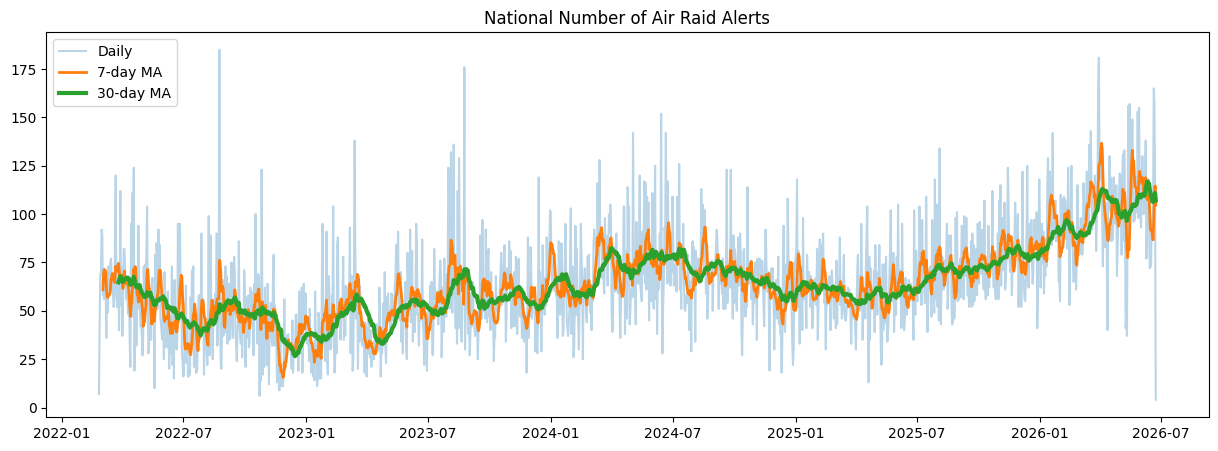

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_alerts["date"],
    daily_alerts["alerts"],
    alpha=.3,
    label="Daily"
)

plt.plot(
    daily_alerts["date"],
    daily_alerts["rolling7"],
    linewidth=2,
    label="7-day MA"
)

plt.plot(
    daily_alerts["date"],
    daily_alerts["rolling30"],
    linewidth=3,
    label="30-day MA"
)

plt.legend()
plt.title("National Number of Air Raid Alerts")
plt.show()

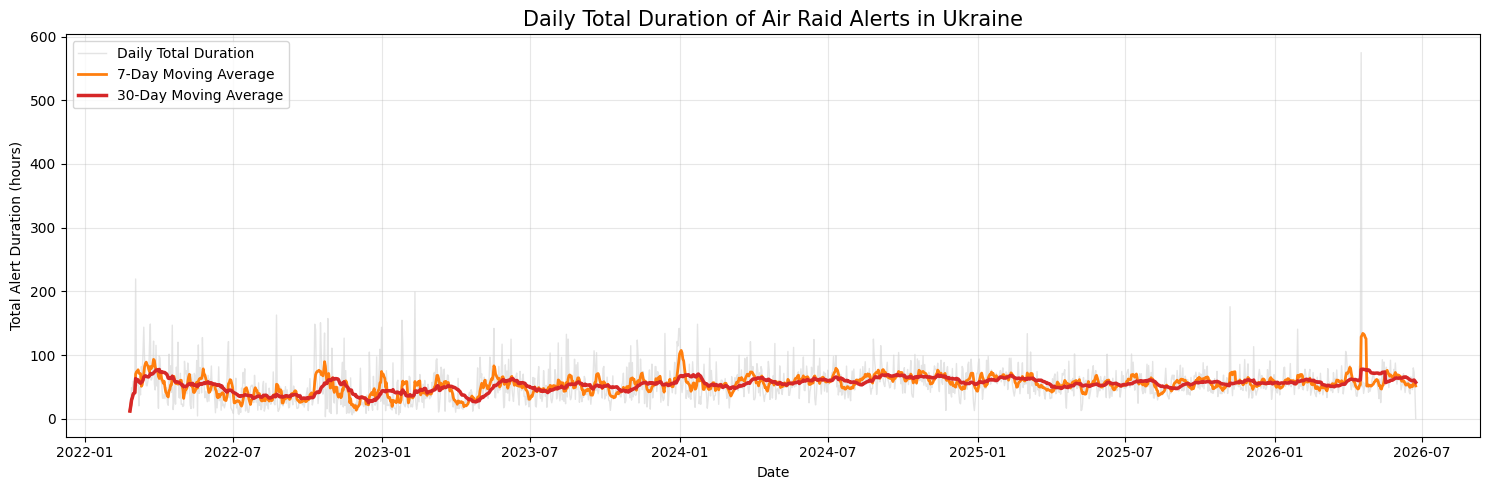

In [16]:
# How many total hours of alerts occurred across all regions combined?
daily_duration = (
    df_v
    .groupby("date")["duration"]
    .sum()
    .reset_index()
)

# Rolling averages
daily_duration["rolling7"] = (
    daily_duration["duration"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_duration["rolling30"] = (
    daily_duration["duration"]
    .rolling(window=30, min_periods=1)
    .mean()
)
daily_duration["duration_hours"] = daily_duration["duration"] / 60
daily_duration["rolling7_hours"] = daily_duration["rolling7"] / 60
daily_duration["rolling30_hours"] = daily_duration["rolling30"] / 60
# Plot
plt.figure(figsize=(15, 5))

plt.plot(
    daily_duration["date"],
    daily_duration["duration_hours"],
    color="lightgray",
    linewidth=1,
    alpha=0.6,
    label="Daily Total Duration"
)

plt.plot(
    daily_duration["date"],
    daily_duration["rolling7_hours"],
    color="tab:orange",
    linewidth=2,
    label="7-Day Moving Average"
)

plt.plot(
    daily_duration["date"],
    daily_duration["rolling30_hours"],
    color="tab:red",
    linewidth=2.5,
    label="30-Day Moving Average"
)

plt.title("Daily Total Duration of Air Raid Alerts in Ukraine", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Total Alert Duration (hours)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_23/1743120942.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(df_v["started_at"].dt.to_period("M"))["duration"]


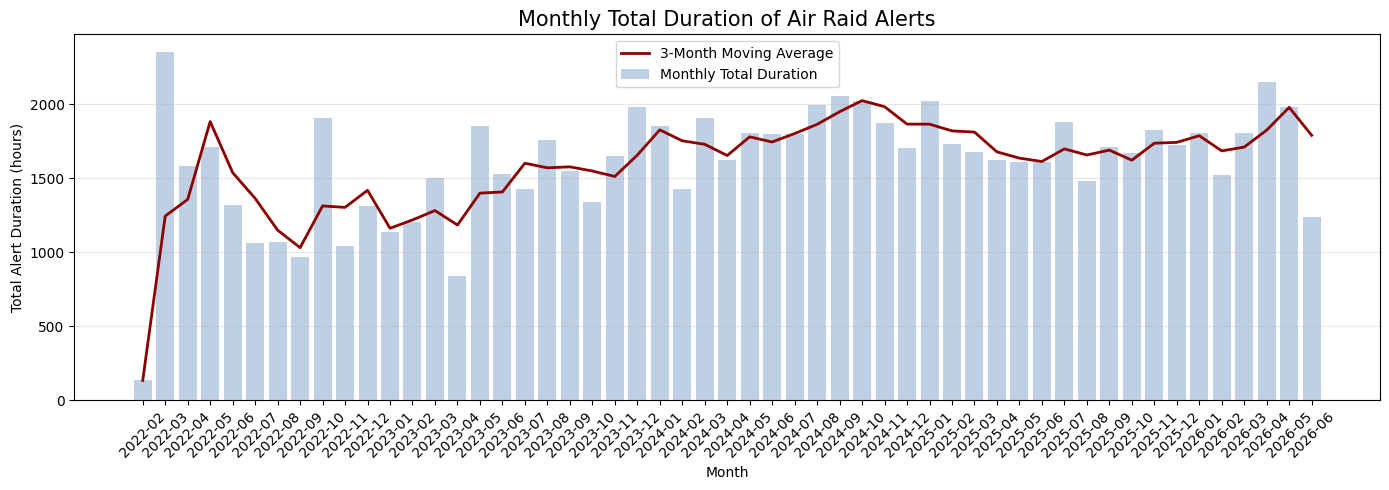

In [17]:
# ensure datetime
df_v["started_at"] = pd.to_datetime(df_v["started_at"], utc=True)

# monthly aggregation (cumulative regional hours)
monthly_duration = (
    df_v
    .groupby(df_v["started_at"].dt.to_period("M"))["duration"]
    .sum()
    .reset_index()
)

# convert period → timestamp (better for plotting)
monthly_duration["started_at"] = monthly_duration["started_at"].astype(str)

# convert minutes → hours
monthly_duration["hours"] = monthly_duration["duration"] / 60

monthly_duration["rolling3"] = (
    monthly_duration["hours"]
    .rolling(window=3, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.bar(
    monthly_duration["started_at"],
    monthly_duration["hours"],
    color="lightsteelblue",
    alpha=0.8,
    label="Monthly Total Duration"
)

plt.plot(
    monthly_duration["started_at"],
    monthly_duration["rolling3"],
    color="darkred",
    linewidth=2,
    label="3-Month Moving Average"
)

plt.title("Monthly Total Duration of Air Raid Alerts", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Total Alert Duration (hours)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 2. Normalized Trend

/tmp/ipykernel_23/3096833001.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_v["month"] = df_v["started_at"].dt.to_period("M")


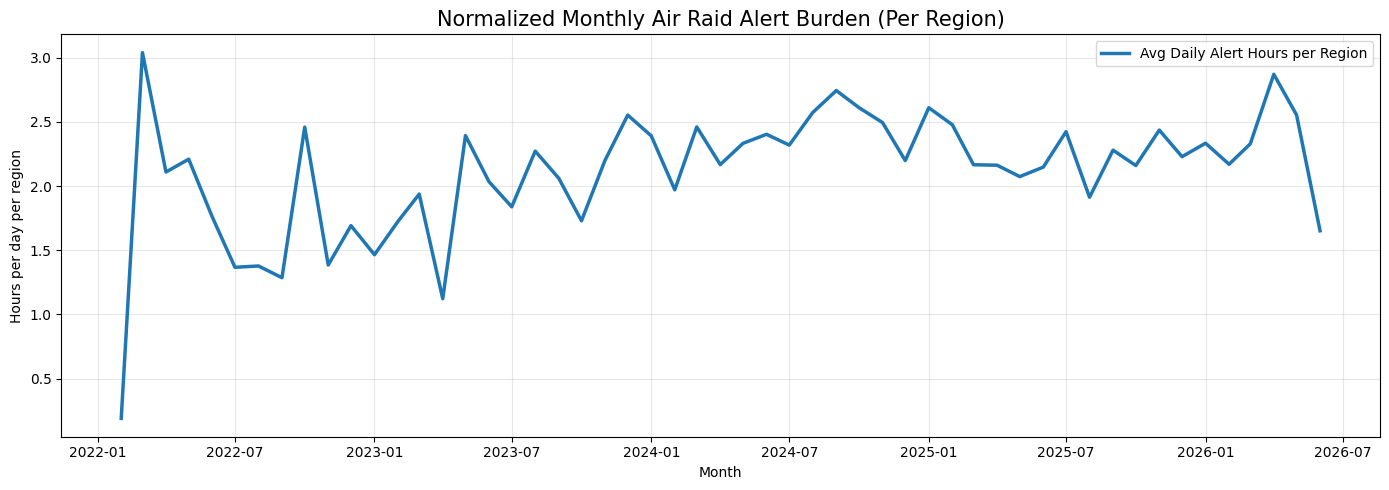

In [18]:
# ensure datetime
df_v["started_at"] = pd.to_datetime(df_v["started_at"], utc=True)

# month grouping
df_v["month"] = df_v["started_at"].dt.to_period("M")

monthly = (
    df_v.groupby("month")["duration"]
    .sum()
    .reset_index()
)

# convert period → timestamp
monthly["month_start"] = monthly["month"].dt.to_timestamp()

# convert to hours
monthly["hours"] = monthly["duration"] / 60

# calendar days in month
monthly["days"] = monthly["month_start"].dt.days_in_month

# number of regions (constant but explicit for clarity)
n_regions = df_v["region"].nunique()

# STEP 1: average daily burden across all regions
monthly["avg_daily_total_hours"] = monthly["hours"] / monthly["days"]

# STEP 2: normalize per region
monthly["avg_daily_per_region_hours"] = monthly["avg_daily_total_hours"] / n_regions

plt.figure(figsize=(14, 5))

plt.plot(
    monthly["month_start"],
    monthly["avg_daily_per_region_hours"],
    linewidth=2.5,
    color="tab:blue",
    label="Avg Daily Alert Hours per Region"
)

plt.title("Normalized Monthly Air Raid Alert Burden (Per Region)", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Hours per day per region")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 3. Daily Cycles

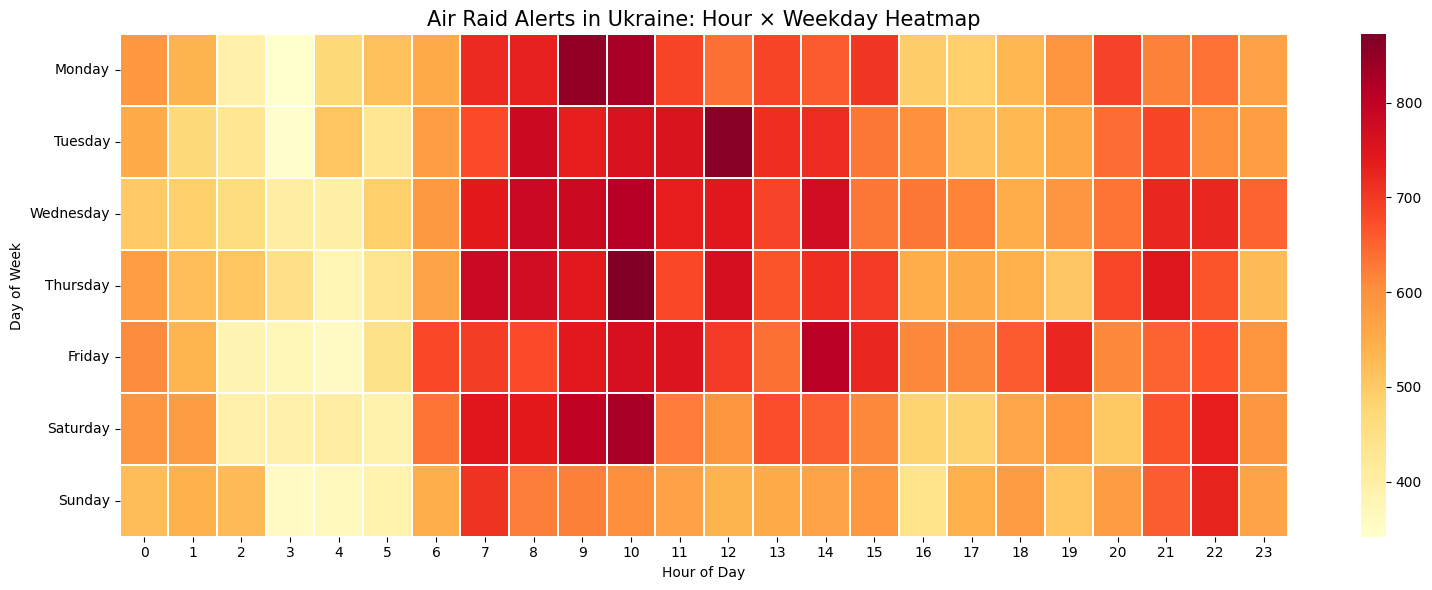

In [19]:
# ensure datetime
df_v["started_at"] = pd.to_datetime(df_v["started_at"], utc=True)

# extract time features (IMPORTANT: use local time if possible later)
df_v["hour"] = df_v["started_at"].dt.hour
df_v["weekday"] = df_v["started_at"].dt.day_name()

# enforce correct weekday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# pivot table: count of alerts
heatmap_data = (
    df_v
    .pivot_table(
        index="weekday",
        columns="hour",
        values="region",
        aggfunc="count"
    )
    .reindex(weekday_order)
)

# plot
plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white"
)

plt.title("Air Raid Alerts in Ukraine: Hour × Weekday Heatmap", fontsize=15)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

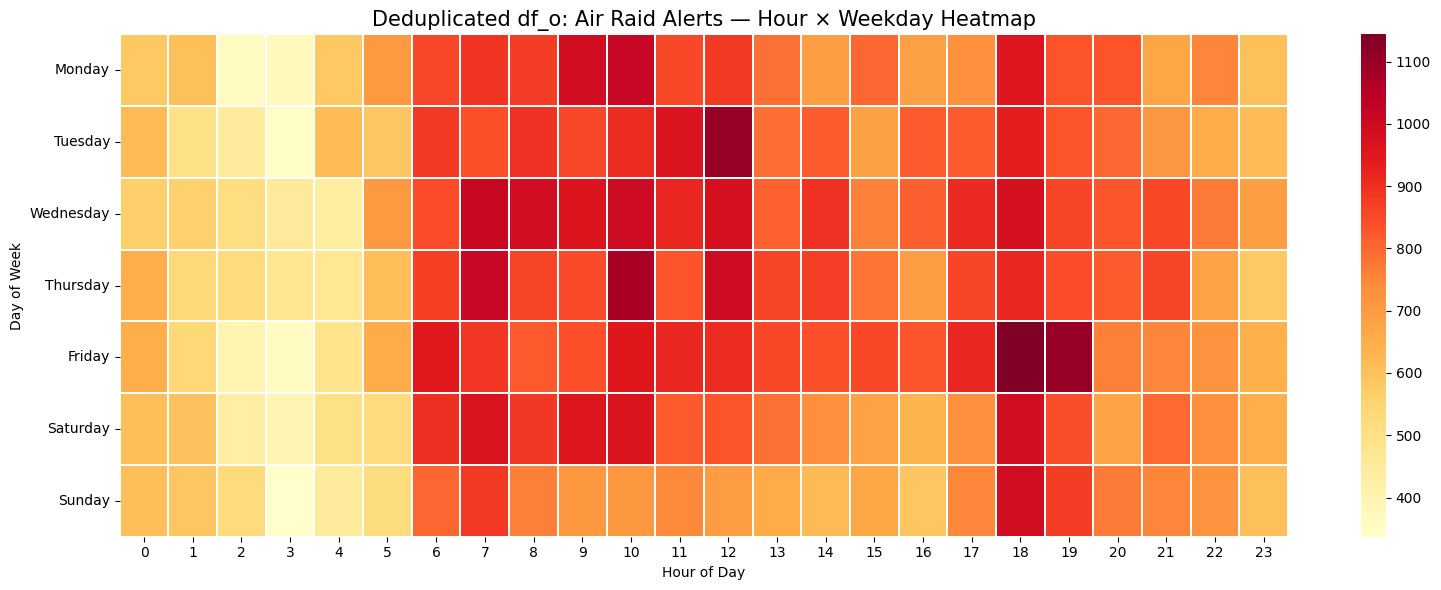

In [20]:


# ---------------------------
# 1. DEDUPLICATION STEP
# ---------------------------
# same alert is repeated across raions → remove duplicates
import pandas as pd

# ---------------------------
# 1. Parse datetime
# ---------------------------
df_o["started_at"] = pd.to_datetime(df_o["started_at"], utc=True)
df_o["finished_at"] = pd.to_datetime(df_o["finished_at"], utc=True)

# ---------------------------
# 2. DROP seconds noise (IMPORTANT)
# ---------------------------
df_o["started_at"] = df_o["started_at"].dt.floor("min")
df_o["finished_at"] = df_o["finished_at"].dt.floor("min")

# ---------------------------
# 3. Remove invalid rows
# ---------------------------
df_o = df_o[df_o["finished_at"] >= df_o["started_at"]].copy()

# ---------------------------
# 4. Remove duplicates (true event duplicates)
# ---------------------------
df_o_clean = df_o.drop_duplicates(
    subset=["oblast", "started_at", "finished_at"]
).copy()

# ---------------------------
# 5. Feature engineering (for analysis)
# ---------------------------
df_o_clean["duration"] = (
    df_o_clean["finished_at"] - df_o_clean["started_at"]
).dt.total_seconds() / 60

df_o_clean["hour"] = df_o_clean["started_at"].dt.hour
df_o_clean["weekday"] = df_o_clean["started_at"].dt.day_name()
# ---------------------------
# 2. FEATURE ENGINEERING
# ---------------------------
df_o_clean["hour"] = df_o_clean["started_at"].dt.hour
df_o_clean["weekday"] = df_o_clean["started_at"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# ---------------------------
# 3. PIVOT TABLE (HEATMAP DATA)
# ---------------------------
heatmap_o = (
    df_o_clean
    .pivot_table(
        index="weekday",
        columns="hour",
        values="oblast",
        aggfunc="count"
    )
    .reindex(weekday_order)
)

# ---------------------------
# 4. PLOT
# ---------------------------
plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_o,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white"
)

plt.title("Deduplicated df_o: Air Raid Alerts — Hour × Weekday Heatmap", fontsize=15)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

(2246, 10)
oblast
Dnipropetrovska oblast     404
Kharkivska oblast          292
Zaporizka oblast           153
Sumska oblast              150
Donetska oblast            146
Mykolaivska oblast         136
Chernihivska oblast        131
Poltavska oblast           128
Khersonska oblast          102
Kirovohradska oblast        95
Kyivska oblast              89
Cherkaska oblast            87
Odeska oblast               69
Kyiv City                   45
Zhytomyrska oblast          40
Vinnytska oblast            34
Rivnenska oblast            25
Khmelnytska oblast          22
Volynska oblast             19
Ivano-Frankivska oblast     17
Zakarpatska oblast          16
Lvivska oblast              16
Ternopilska oblast          16
Chernivetska oblast         14
Name: count, dtype: int64


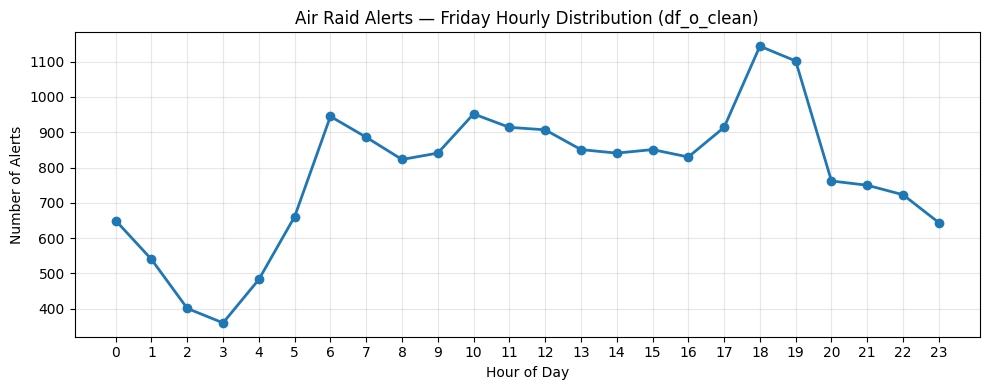

In [21]:
friday_data = df_o_clean[df_o_clean["weekday"] == "Friday"].copy()
friday_hourly = (
    friday_data
    .groupby("hour")
    .size()
    .sort_index()
)

plt.figure(figsize=(10, 4))

plt.plot(
    friday_hourly.index,
    friday_hourly.values,
    marker="o",
    linewidth=2
)
print(friday_data[
    (friday_data["hour"] == 18) | (friday_data["hour"] == 19)
].shape)
print(friday_data[
    (friday_data["hour"] == 18) | (friday_data["hour"] == 19)
]["oblast"].value_counts())
plt.title("Air Raid Alerts — Friday Hourly Distribution (df_o_clean)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Alerts")
plt.grid(alpha=0.3)

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [22]:
df_o_clean.groupby(
    ["oblast", "started_at", "finished_at"]
).size().sort_values(ascending=False).head(20)

oblast            started_at                 finished_at              
Cherkaska oblast  2022-03-15 16:11:00+00:00  2022-03-15 16:54:00+00:00    1
                  2022-03-15 18:04:00+00:00  2022-03-15 18:35:00+00:00    1
                  2022-03-16 00:50:00+00:00  2022-03-16 04:42:00+00:00    1
                  2022-03-16 09:47:00+00:00  2022-03-16 10:45:00+00:00    1
                  2022-03-16 10:11:00+00:00  2022-03-16 10:45:00+00:00    1
                  2022-03-16 10:12:00+00:00  2022-03-16 10:45:00+00:00    1
                  2022-03-16 11:35:00+00:00  2022-03-16 13:12:00+00:00    1
                  2022-03-16 15:51:00+00:00  2022-03-16 17:23:00+00:00    1
                  2022-03-16 17:12:00+00:00  2022-03-16 17:23:00+00:00    1
                  2022-03-17 01:33:00+00:00  2022-03-17 03:10:00+00:00    1
                  2022-03-17 09:16:00+00:00  2022-03-17 09:16:00+00:00    1
                  2022-03-18 03:33:00+00:00  2022-03-18 04:38:00+00:00    1
                 

In [23]:
df_o_dedup = df_o_clean.drop_duplicates(
    subset=["oblast", "started_at", "finished_at"]
).copy()
print("Original:", len(df_o))
print("After cleaning:", len(df_o_dedup))

Original: 272699
After cleaning: 126421


## Regional Risk Analysis

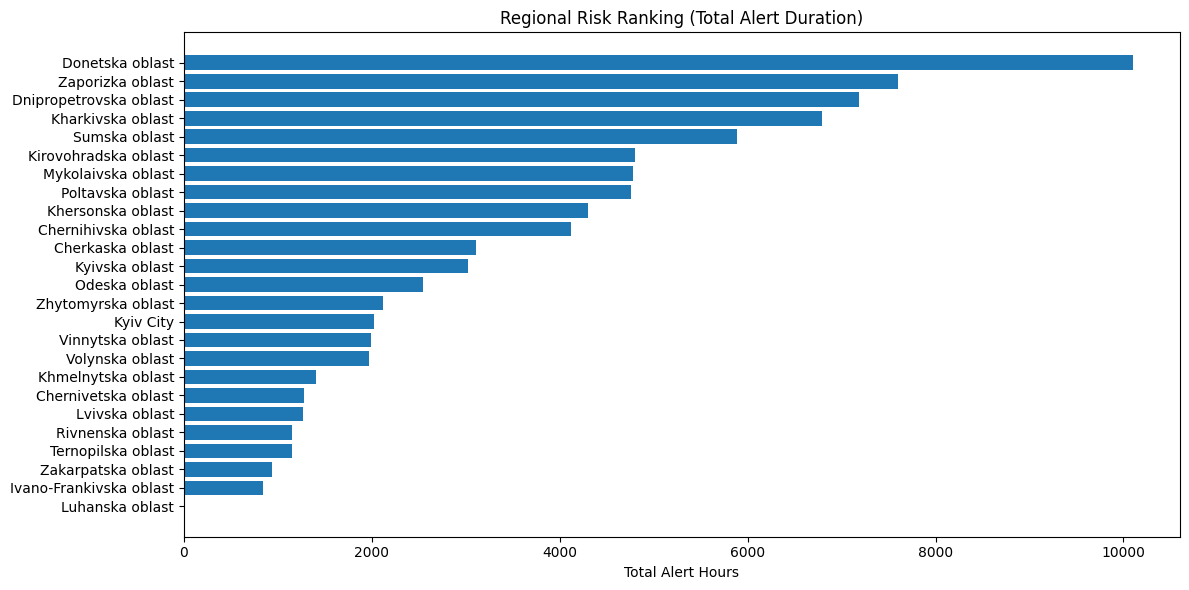

In [24]:
df_v["started_at"] = pd.to_datetime(df_v["started_at"], utc=True)
df_v["date"] = df_v["started_at"].dt.date
oblast_ranking = (
    df_v.groupby("region")["duration"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

oblast_ranking["hours"] = oblast_ranking["duration"] / 60
plt.figure(figsize=(12,6))

plt.barh(
    oblast_ranking["region"],
    oblast_ranking["hours"]
)

plt.gca().invert_yaxis()

plt.title("Regional Risk Ranking (Total Alert Duration)")
plt.xlabel("Total Alert Hours")

plt.tight_layout()
plt.show()

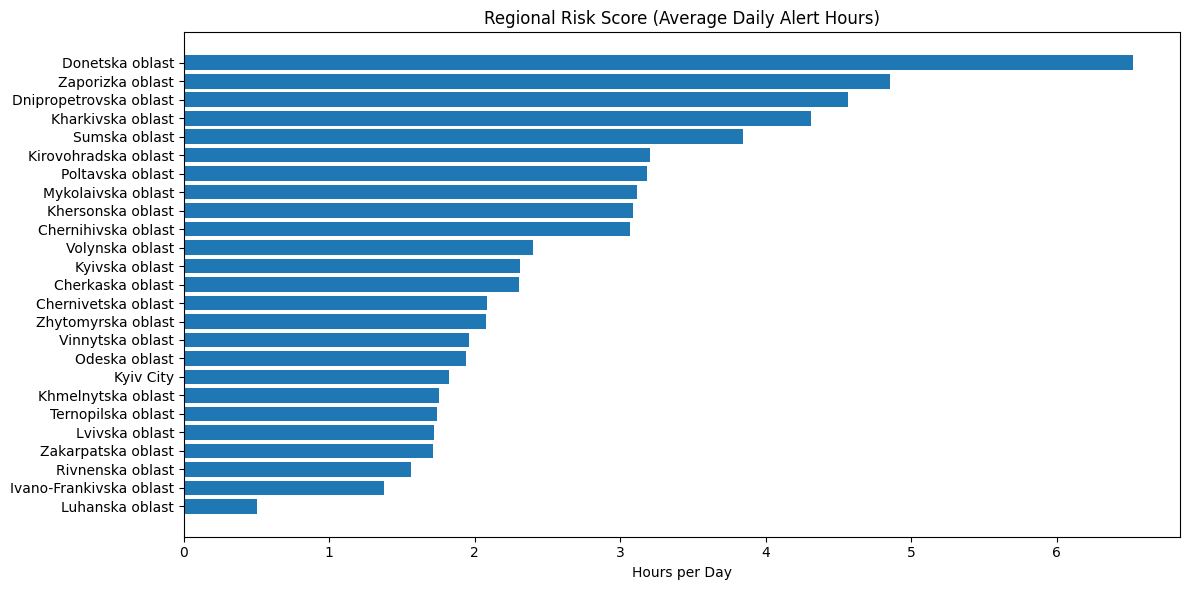

In [25]:
daily_region = (
    df_v.groupby(["date", "region"])["duration"]
    .sum()
    .reset_index()
)

daily_region["hours"] = daily_region["duration"] / 60

risk_score = (
    daily_region.groupby("region")["hours"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

risk_score.columns = ["region", "avg_daily_hours"]

plt.figure(figsize=(12,6))

plt.barh(
    risk_score["region"],
    risk_score["avg_daily_hours"]
)

plt.gca().invert_yaxis()

plt.title("Regional Risk Score (Average Daily Alert Hours)")
plt.xlabel("Hours per Day")

plt.tight_layout()
plt.show()

### DYNAMIC RISK SCORE

/tmp/ipykernel_23/3619523931.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.set_index("date")["hours"].rolling(30).mean())


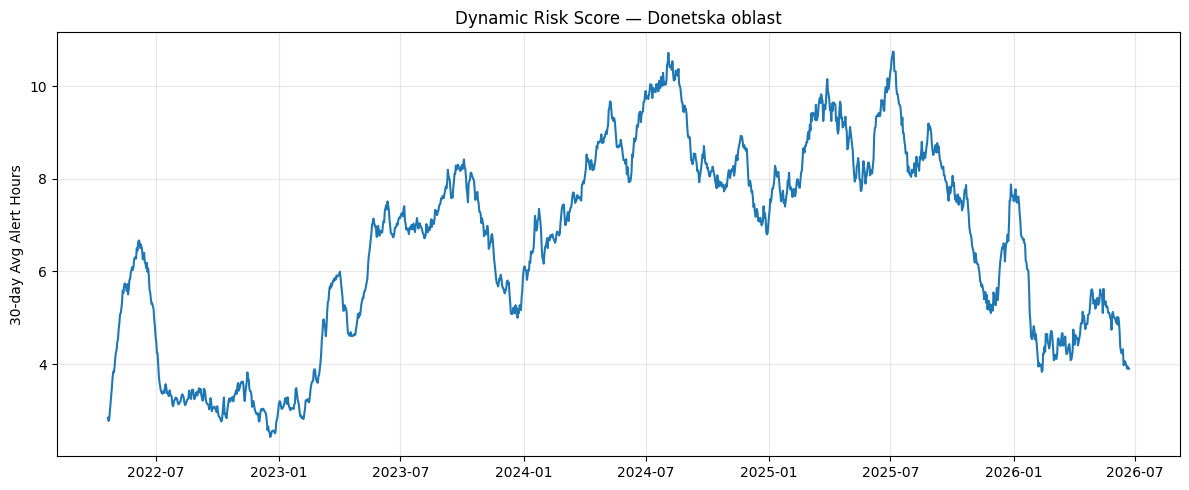

In [26]:
daily_region["date"] = pd.to_datetime(daily_region["date"])

rolling_risk = (
    daily_region
    .groupby("region")
    .apply(lambda x: x.set_index("date")["hours"].rolling(30).mean())
    .reset_index()
)
top_region = risk_score.iloc[0]["region"]

top_data = daily_region[daily_region["region"] == top_region]

top_data = top_data.set_index("date").sort_index()

top_data["rolling30"] = top_data["hours"].rolling(30).mean()

plt.figure(figsize=(12,5))

plt.plot(top_data.index, top_data["rolling30"])

plt.title(f"Dynamic Risk Score — {top_region}")
plt.ylabel("30-day Avg Alert Hours")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PEACE WINDOWS

In [27]:
df_v["started_at"] = pd.to_datetime(df_v["started_at"], utc=True)
df_v["finished_at"] = pd.to_datetime(df_v["finished_at"], utc=True)

df_sorted = df_v.sort_values(["region", "started_at"]).copy()

df_sorted["prev_end"] = df_sorted.groupby("region")["finished_at"].shift(1)

df_sorted["peace_window"] = (
    df_sorted["started_at"] - df_sorted["prev_end"]
).dt.total_seconds() / 3600

peace = df_sorted[df_sorted["peace_window"] > 0].copy()

longest_peace = (
    peace.groupby("region")["peace_window"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

longest_peace.columns = ["region", "max_peace_hours"]

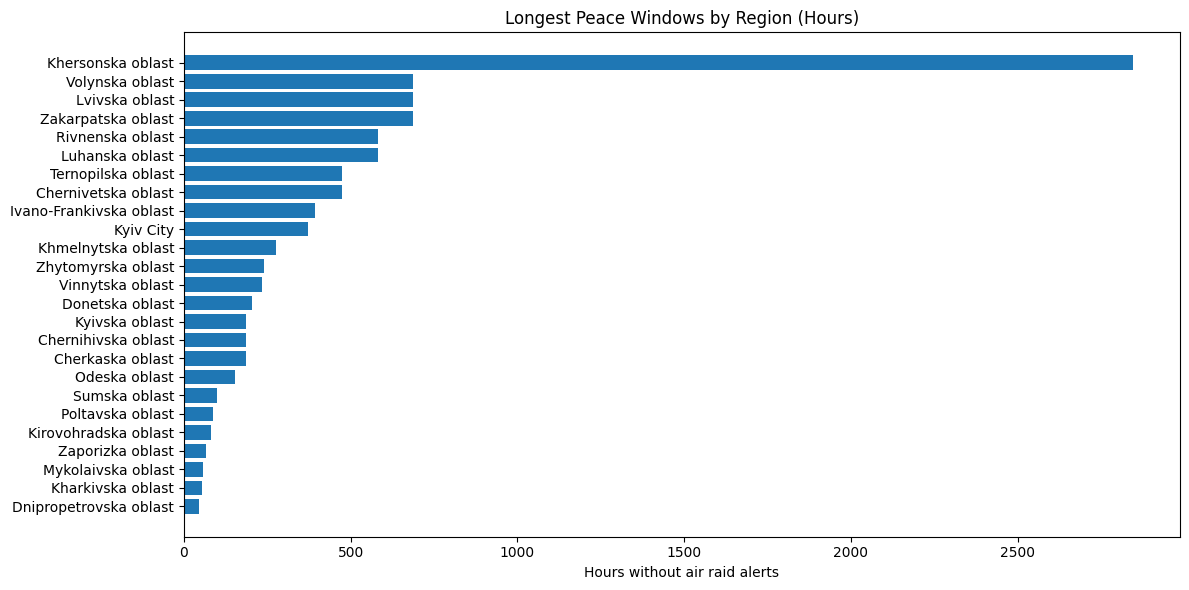

In [28]:
plt.figure(figsize=(12,6))

plt.barh(
    longest_peace["region"],
    longest_peace["max_peace_hours"]
)

plt.gca().invert_yaxis()

plt.title("Longest Peace Windows by Region (Hours)")
plt.xlabel("Hours without air raid alerts")

plt.tight_layout()
plt.show()

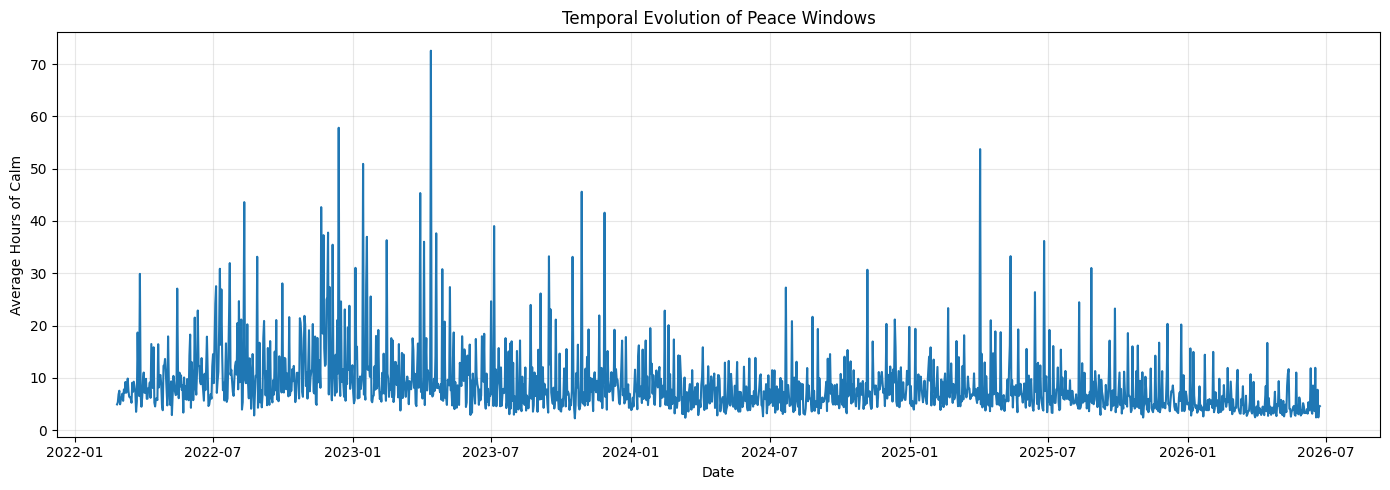

In [29]:
peace["date"] = peace["started_at"].dt.date
daily_peace = (
    peace.groupby("date")["peace_window"]
    .mean()
    .reset_index()
)

daily_peace["date"] = pd.to_datetime(daily_peace["date"])
plt.figure(figsize=(14,5))

plt.plot(
    daily_peace["date"],
    daily_peace["peace_window"]
)

plt.title("Temporal Evolution of Peace Windows")
plt.ylabel("Average Hours of Calm")
plt.xlabel("Date")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

df_v["started_at"] = pd.to_datetime(df_v["started_at"], utc=True)
df_v["date"] = df_v["started_at"].dt.date

daily = (
    df_v.groupby("date")["duration"]
    .sum()
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily["hours"] = daily["duration"] / 60

ts = daily.set_index("date")["hours"].asfreq("D")
ts = ts.fillna(0)

In [31]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# train-test split
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ARIMA model (simple baseline)
model = ARIMA(train, order=(5,1,2))
model_fit = model.fit()

# forecast
forecast_arima = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


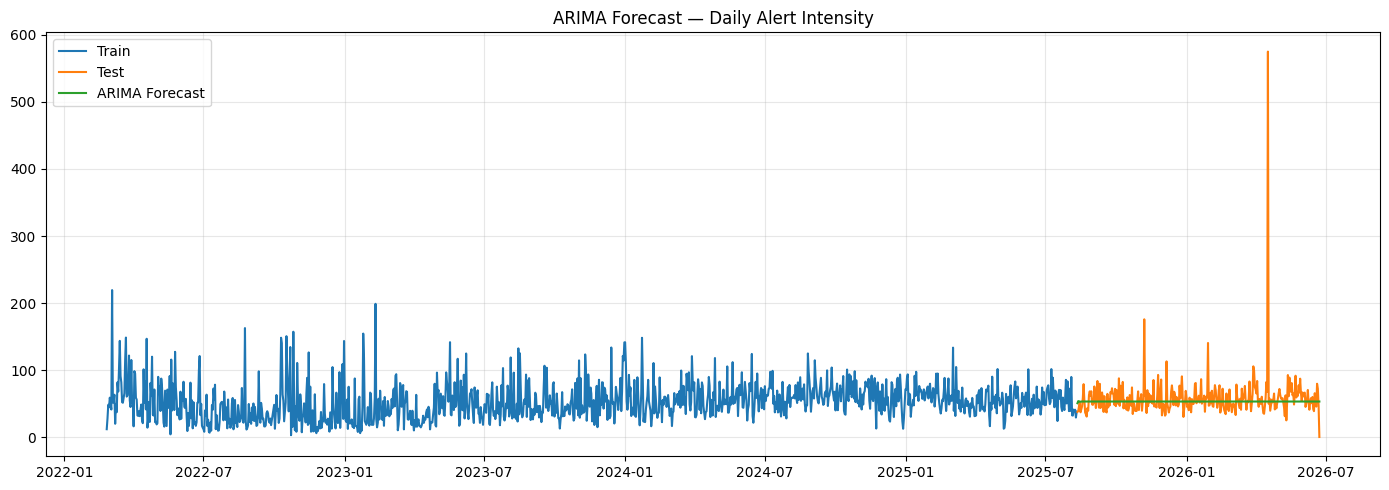

In [32]:
plt.figure(figsize=(14,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_arima, label="ARIMA Forecast")

plt.title("ARIMA Forecast — Daily Alert Intensity")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
from prophet import Prophet

prophet_df = daily.rename(columns={
    "date": "ds",
    "hours": "y"
})[["ds", "y"]]

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(prophet_df)

18:59:57 - cmdstanpy - INFO - Chain [1] start processing
18:59:58 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

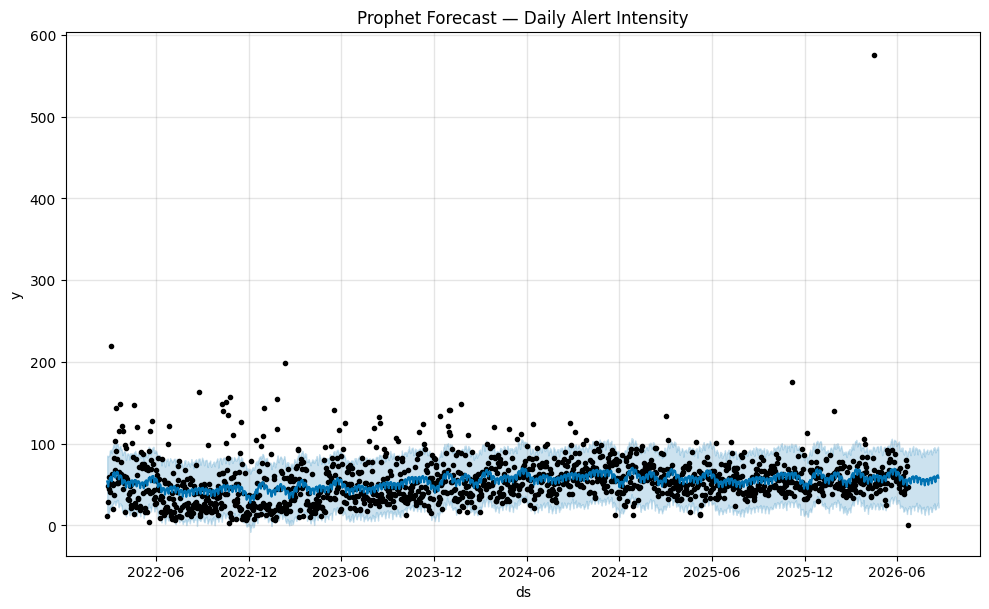

In [35]:
fig = model.plot(forecast)
plt.title("Prophet Forecast — Daily Alert Intensity")
plt.show()

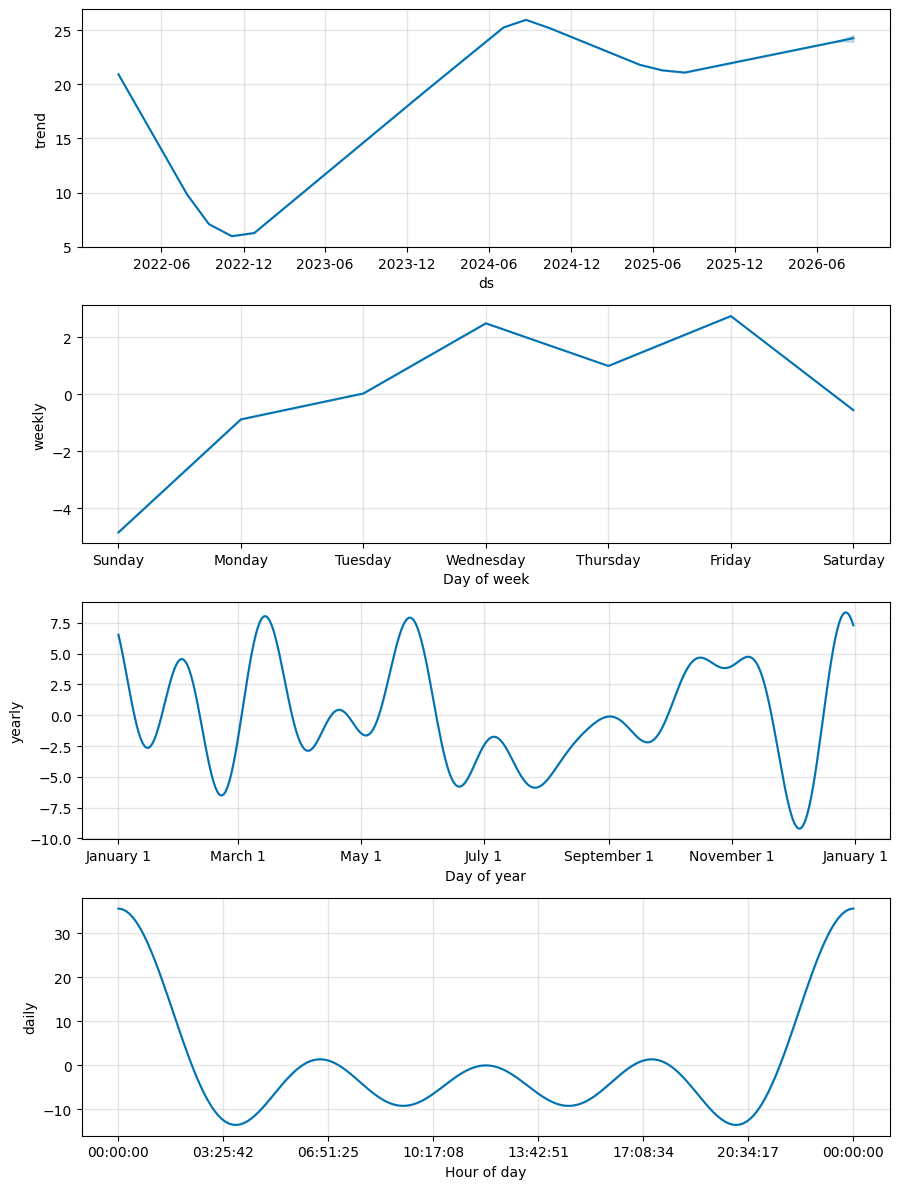

In [36]:
fig2 = model.plot_components(forecast)
plt.show()

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test.values
y_pred_arima = forecast_arima[:len(y_true)]

mae_arima = mean_absolute_error(y_true, y_pred_arima)

mae_arima

13.720115062042346

In [38]:
rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred_arima))

rmse_arima

np.float64(33.95376082839947)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
19:00:01 - cmdstanpy - INFO - Chain [1] start processing
19:00:02 - cmdstanpy - INFO - Chain [1] done processing


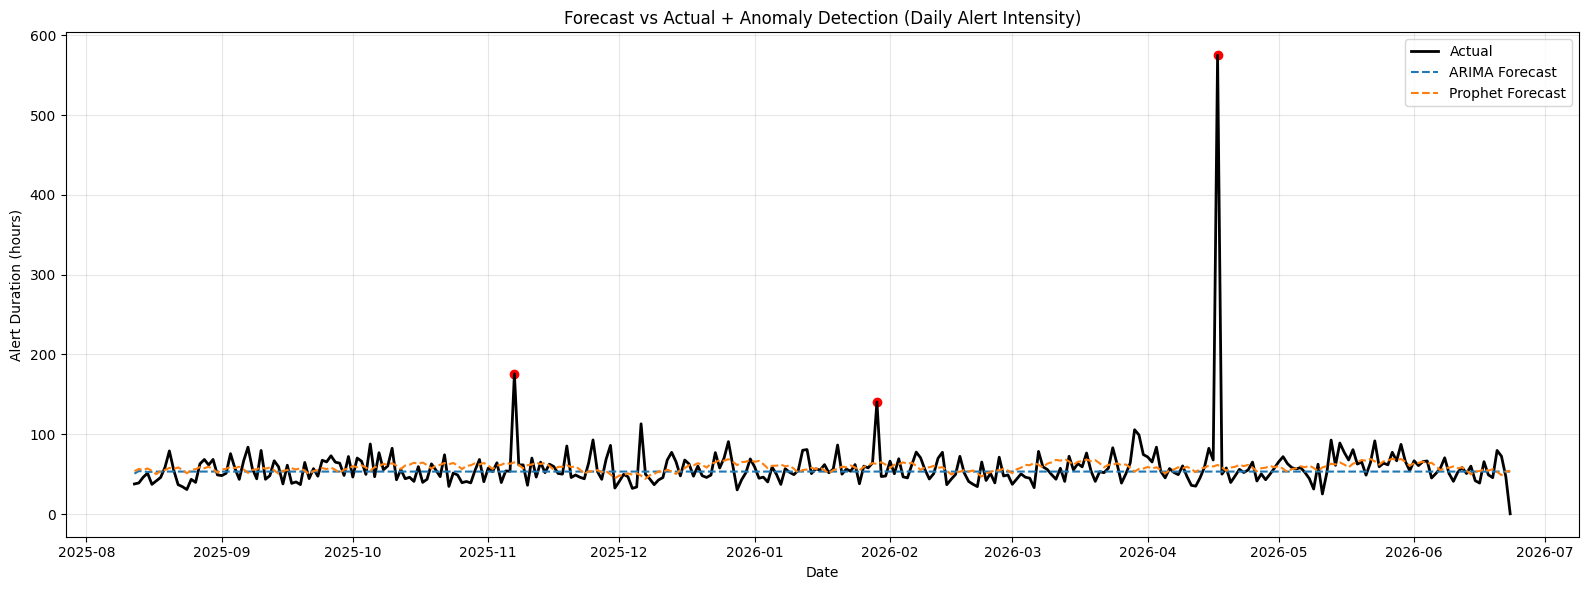

In [39]:
# ---------------------------
# 1. DAILY TIME SERIES
# ---------------------------
df_v["started_at"] = pd.to_datetime(df_v["started_at"], utc=True)
df_v["date"] = df_v["started_at"].dt.date

daily = (
    df_v.groupby("date")["duration"]
    .sum()
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily["hours"] = daily["duration"] / 60

# IMPORTANT: do NOT force 0 for missing days
ts = daily.set_index("date")["hours"].asfreq("D")

# optional but safer than fillna(0)
ts = ts.interpolate()

# ---------------------------
# 2. TRAIN / TEST SPLIT
# ---------------------------
train_size = int(len(ts) * 0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

# ---------------------------
# 3. ARIMA MODEL
# ---------------------------
arima_model = ARIMA(train, order=(5,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index  # FIX ALIGNMENT

# ---------------------------
# 4. PROPHET MODEL
# ---------------------------
prophet_df = daily.rename(columns={"date": "ds", "hours": "y"})[["ds", "y"]]

m = Prophet(daily_seasonality=True, weekly_seasonality=True)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)

# FIX ALIGNMENT PROPERLY
prophet_forecast = (
    forecast.set_index("ds")["yhat"]
    .reindex(test.index)
)

# ---------------------------
# 5. ANOMALIES (FULL SERIES)
# ---------------------------
test_z = (test - test.mean()) / test.std()
anomalies = test[test_z > 2]

# ---------------------------
# 6. PLOT (CLEAN & CORRECT)
# ---------------------------
plt.figure(figsize=(16,6))

# actual
plt.plot(test.index, test.values, label="Actual", color="black", linewidth=2)

# ARIMA
plt.plot(test.index, arima_forecast.values, label="ARIMA Forecast", linestyle="--")

# Prophet
plt.plot(test.index, prophet_forecast.values, label="Prophet Forecast", linestyle="--")

# anomalies
plt.scatter(anomalies.index, anomalies.values, color="red")

plt.title("Forecast vs Actual + Anomaly Detection (Daily Alert Intensity)")
plt.xlabel("Date")
plt.ylabel("Alert Duration (hours)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
# ensure alignment
y_true = test.values
y_pred = prophet_forecast[:len(y_true)]

mae_prophet = mean_absolute_error(y_true, y_pred)

mae_prophet

from sklearn.metrics import mean_squared_error

rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred))

rmse_prophet

np.float64(33.367763983562654)

In [41]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "MAE": [mae_arima, mae_prophet],
    "RMSE": [rmse_arima, rmse_prophet]
})

results

,Model,MAE,RMSE
0,ARIMA,13.720115,33.953761
1,Prophet,13.948895,33.367764
